## Step 1: Observable churn

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
data_path = "../data/raw/"

df_train = pd.read_csv(data_path+"train_v2.csv")

df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   msno      970960 non-null  str  
 1   is_churn  970960 non-null  int64
dtypes: int64(1), str(1)
memory usage: 55.6 MB


In [6]:
df_train.head()

,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1


In [8]:
df_train.shape

(970960, 2)

In [9]:
df_train['is_churn'].value_counts(normalize = True)


is_churn
0    0.910058
1    0.089942
Name: proportion, dtype: float64

In [12]:
df_train.isna().mean()*100

msno        0.0
is_churn    0.0
dtype: float64

## Step 2: Value dispersion

In [13]:
df_transactions = pd.read_csv(data_path+'transactions_v2.csv')

df_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1431009 entries, 0 to 1431008
Data columns (total 9 columns):
 #   Column                  Non-Null Count    Dtype
---  ------                  --------------    -----
 0   msno                    1431009 non-null  str  
 1   payment_method_id       1431009 non-null  int64
 2   payment_plan_days       1431009 non-null  int64
 3   plan_list_price         1431009 non-null  int64
 4   actual_amount_paid      1431009 non-null  int64
 5   is_auto_renew           1431009 non-null  int64
 6   transaction_date        1431009 non-null  int64
 7   membership_expire_date  1431009 non-null  int64
 8   is_cancel               1431009 non-null  int64
dtypes: int64(8), str(1)
memory usage: 158.3 MB


In [ ]:
df_transactions.head()

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=,32,90,298,298,0,20170131,20170504,0
1,++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=,41,30,149,149,1,20150809,20190412,0
2,+/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=,36,30,180,180,1,20170303,20170422,0
3,+/w1UrZwyka4C9oNH3+Q8fUf3fD8R3EwWrx57ODIsqk=,36,30,180,180,1,20170329,20170331,1
4,+00PGzKTYqtnb65mPKPyeHXcZEwqiEzktpQksaaSC3c=,41,30,99,99,1,20170323,20170423,0


In [61]:
df_transactions['plan_list_price'].nunique()

48

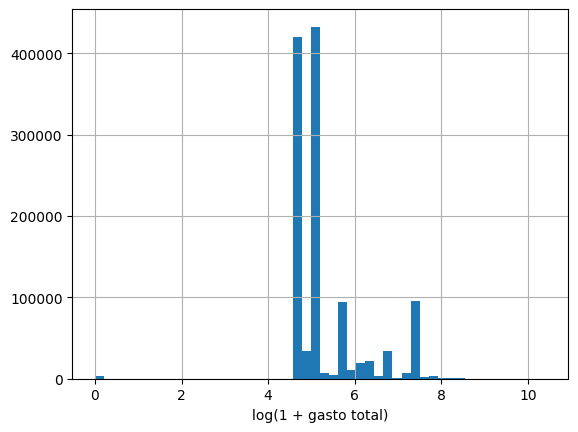

In [23]:
agg = df_transactions.groupby('msno')['actual_amount_paid'].sum()

np.log1p(agg).hist(bins=50)
plt.xlabel('log(1 + gasto total)')
plt.show()


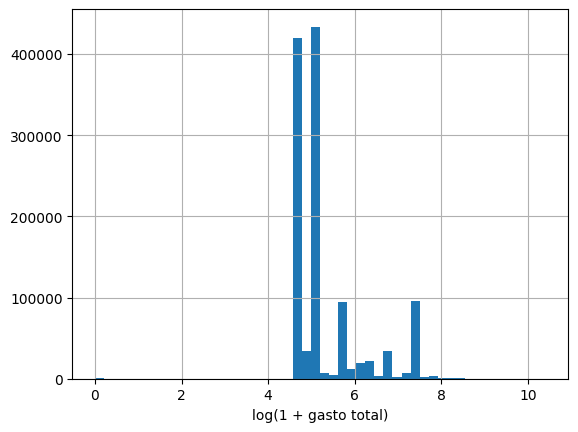

In [24]:
agg = df_transactions.groupby('msno')['plan_list_price'].sum()

np.log1p(agg).hist(bins=50)
plt.xlabel('log(1 + gasto total)')
plt.show()

It seems that most of the users have only 1 accumulated payment, because there iis a big mass in aprox 4,6 which is equivalent to 99 NTD and another big one in 5,1 which is 160NTD. This data set was supposed to be historical, lets check how many registers do we have per user.

In [30]:
df_transactions['transaction_date'].min()

np.int64(20150101)

In [31]:
df_transactions['transaction_date'].max()

np.int64(20170331)

In [27]:
df_transactions.groupby('msno').size().describe()

count    1.197050e+06
mean     1.195446e+00
std      1.206252e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      2.080000e+02
dtype: float64

In [34]:
df_transactions_completed = pd.read_csv(data_path+'transactions.csv')
df_transactions_completed.groupby('msno').size().describe()

count    2.363626e+06
mean     9.116394e+00
std      8.887318e+00
min      1.000000e+00
25%      1.000000e+00
50%      5.000000e+00
75%      1.600000e+01
max      7.100000e+01
dtype: float64

In [36]:
df_transactions_completed['transaction_date'].max()

np.int64(20170228)

In [35]:
(df_transactions['transaction_date'] // 100).value_counts().sort_index()

transaction_date
201501       1169
201502       1504
201503       3371
201504       3579
201505       4393
201506       5179
201507       6247
201508       7095
201509       7692
201510       9222
201511      11295
201512      10620
201601       2607
201602       7042
201603       8262
201604       7967
201605       7431
201606       7140
201607       8516
201608       8134
201609      10586
201610      17743
201611      18819
201612      23787
201701      32871
201702     128916
201703    1069822
Name: count, dtype: int64

We can see how the transactionsV2 was meant to be the incremental registers of march 017, although it has some registers from previoous dates. To obtain the full image in one data set, I will concatenate both and remove duplicates.

In [38]:
df_transactions_v3 = pd.concat([df_transactions,df_transactions_completed], ignore_index = True)

df_transactions_v3.duplicated().sum()

np.int64(3339)

In [39]:
df_transactions_v3.drop_duplicates(inplace=True)

np.int64(0)

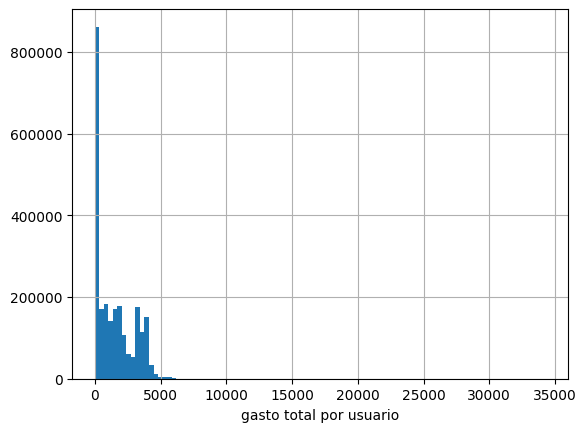

In [ ]:
agg = df_transactions_v3.groupby('msno')['actual_amount_paid'].sum()

agg.hist(bins=100)  
plt.xlabel('gasto total por usuario')
plt.show()


In [ ]:
df_transactions_v3.groupby('msno').size().describe()

count    2.426143e+06
mean     9.469935e+00
std      9.293833e+00
min      1.000000e+00
25%      2.000000e+00
50%      5.000000e+00
75%      1.600000e+01
max      2.440000e+02
dtype: float64

With the combined transactions data (v1 + v2, deduplicated) we can confirm that the 
dataset supports the project's core thesis (viability checklist, point 4): total 
spend per user shows real dispersion — from single-payment users (~150 NTD) up to 
long-tenured customers above 5,000 NTD, with a long tail reaching ~35,000 NTD — 
driven by two independent sources: plan mix and customer tenure (median 5 
transactions/user, p75 = 16). This means ranking customers by value-at-risk will 
genuinely reorder the list relative to ranking by churn probability alone, which 
is the premise the entire optimization rests on.

In [58]:
df_transactions_v3.to_csv("../data/processed/transactions_2015_2017-03.csv", index=False)


## Features pre-churn

In [49]:
df_members = pd.read_csv(data_path+'members_v3.csv')

df_members.info()

<class 'pandas.DataFrame'>
RangeIndex: 6769473 entries, 0 to 6769472
Data columns (total 6 columns):
 #   Column                  Dtype
---  ------                  -----
 0   msno                    str  
 1   city                    int64
 2   bd                      int64
 3   gender                  str  
 4   registered_via          int64
 5   registration_init_time  int64
dtypes: int64(4), str(2)
memory usage: 605.9 MB


In [51]:
df_members.head()

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [52]:
df_members.isna().mean()

msno                      0.000000
city                      0.000000
bd                        0.000000
gender                    0.654335
registered_via            0.000000
registration_init_time    0.000000
dtype: float64

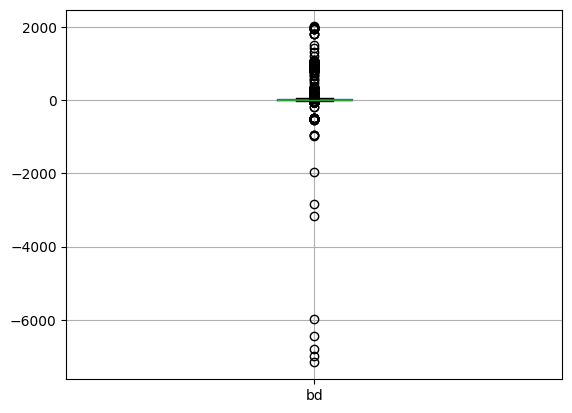

In [ ]:
df_members.boxplot(column = 'bd')
plt.show()

Columns bd (age) and gener will need preprocessing